# 📊 AutoEDA - Análisis Exploratorio de Datos CCL
Este notebook realiza un análisis exploratorio automático de los datos de señal CCL (Casing Collar Locator) y tensión (TENS) registrados por etapa, pozo y dirección de corrida ("sentido").

El objetivo es:
- Entender la distribución y comportamiento de los datos.
- Visualizar posibles patrones o anomalías.
- Dejar preparado el dataset para futuras fases de modelado.


## 💻 Celda 2 - Importación de librerías

In [1]:
# Carga de librerías principales para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Herramientas de AutoEDA
import sweetviz
from ydata_profiling import ProfileReport

# Configuración visual
sns.set(style="whitegrid")
%matplotlib inline

# Mostrar archivos en el directorio actual
print("Archivos disponibles:")
print(os.listdir())

Archivos disponibles:
['01_autoeda_ccl.ipynb', 'franco.txt', 'sweetviz_report.html']


## 📂 Celda 3 - Carga de datos

In [10]:
# Ruta del archivo CSV de ejemplo (ajustar si es necesario)
df = pd.read_csv(r"C:\Developer\fundamentos\data\salida_DEPT_CCL_TENS_EXTENDIDA.csv")

# Vista rápida
df.head()


,DEPT,CCL,TENS,archivo_origen,pozo,sentido,etapa
0,2944.9776,0.01788,848.99997,BPO-2703_E2_Down__27Jan25_093950.las,BPO-2703,Down,E2
1,2945.1300,-0.02459,848.99997,BPO-2703_E2_Down__27Jan25_093950.las,BPO-2703,Down,E2
2,2945.2824,-0.01184,843.99999,BPO-2703_E2_Down__27Jan25_093950.las,BPO-2703,Down,E2
3,2945.4348,0.01421,840.99991,BPO-2703_E2_Down__27Jan25_093950.las,BPO-2703,Down,E2
4,2945.5872,0.01243,839.99996,BPO-2703_E2_Down__27Jan25_093950.las,BPO-2703,Down,E2


## 📏 Celda 4 - Revisión general del dataset

In [11]:
# Info general del dataframe
df.info()

# Revisión de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas básicas
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858423 entries, 0 to 858422
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DEPT            858423 non-null  float64
 1   CCL             858309 non-null  float64
 2   TENS            858341 non-null  float64
 3   archivo_origen  858423 non-null  object 
 4   pozo            858423 non-null  object 
 5   sentido         858423 non-null  object 
 6   etapa           858423 non-null  object 
dtypes: float64(3), object(4)
memory usage: 45.8+ MB

Valores nulos por columna:
DEPT                0
CCL               114
TENS               82
archivo_origen      0
pozo                0
sentido             0
etapa               0
dtype: int64


,DEPT,CCL,TENS
count,858423.000000,858309.000000,858341.000000
mean,3877.113195,0.000955,1539.631629
std,737.116391,0.080204,729.563766
min,2499.969600,-11.952720,283.000060
25%,3268.675200,-0.004270,837.000110
50%,3792.169200,0.000820,1087.000020
75%,4403.445600,0.005540,2264.999560
max,5822.899200,31.835000,3204.999940


## 🧭 Celda 5 - Análisis de distribución de variables numéricas

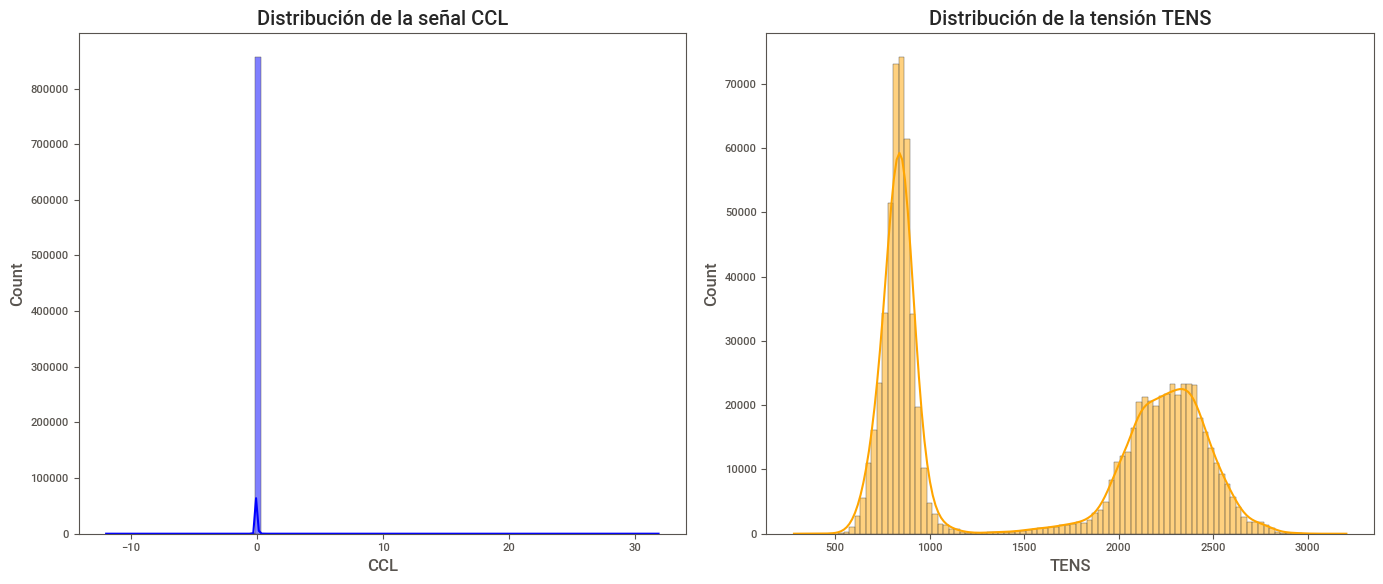

In [12]:
# Histogramas generales de CCL y TENS
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['CCL'], bins=100, kde=True, color='blue')
plt.title("Distribución de la señal CCL")

plt.subplot(1, 2, 2)
sns.histplot(df['TENS'], bins=100, kde=True, color='orange')
plt.title("Distribución de la tensión TENS")

plt.tight_layout()
plt.show()


### 📈 Celda 5.1 - Análisis de correlaciones entre variables numéricas

#### 🔗 Análisis de correlaciones numéricas

A continuación se muestra la matriz de correlación entre las variables numéricas del dataset. Esto permite detectar relaciones lineales fuertes o débiles entre `CCL`, `TENS` y `DEPT`.


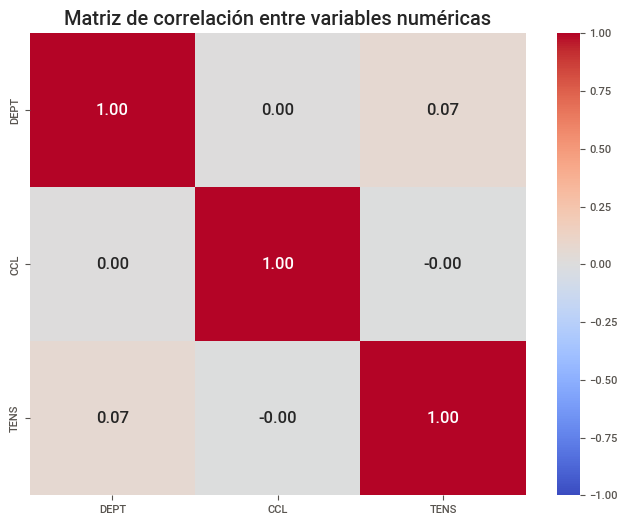

In [13]:
# Seleccionamos solo columnas numéricas para evitar errores
num_cols = df.select_dtypes(include=np.number)

# Calculamos la matriz de correlación
corr_matrix = num_cols.corr()

# Graficamos la matriz
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


## 🛠 Celda 6 - Análisis por dirección (sentido)

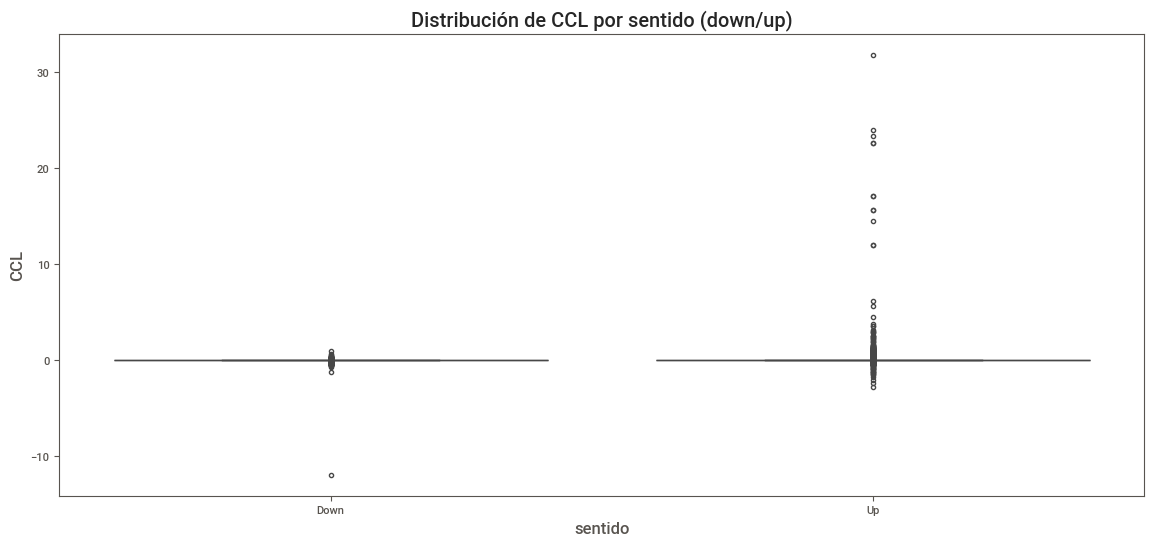

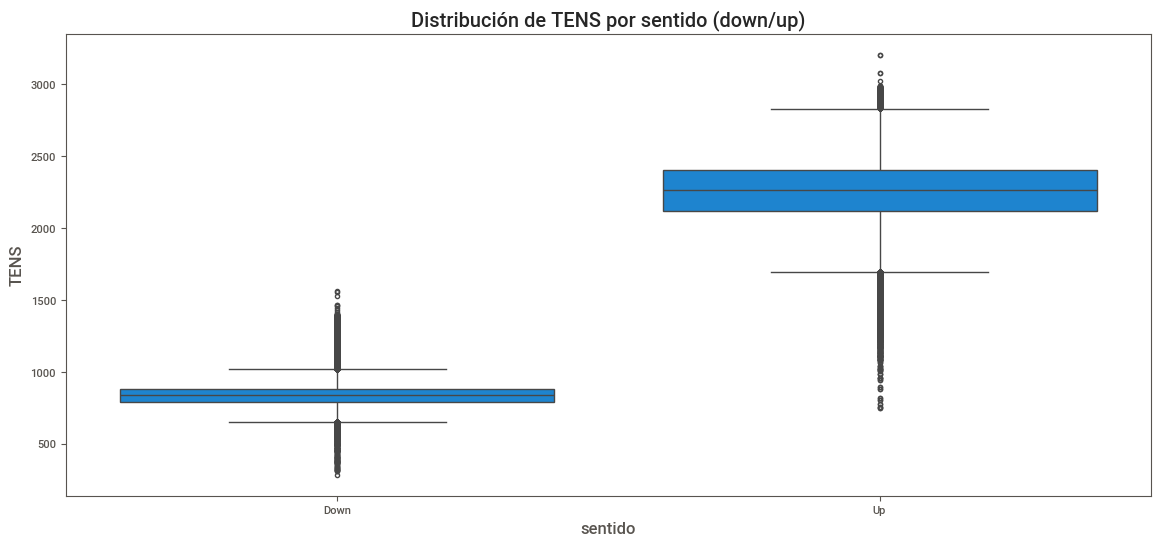

In [14]:
# Comparamos CCL y TENS según 'sentido' (down vs up)
plt.figure(figsize=(14, 6))

sns.boxplot(data=df, x="sentido", y="CCL")
plt.title("Distribución de CCL por sentido (down/up)")
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="sentido", y="TENS")
plt.title("Distribución de TENS por sentido (down/up)")
plt.show()


## 🧪 Celda 7 - Exploración por pozo y etapa

Etapas por pozo:
pozo
BPO-2703    32
Name: etapa, dtype: int64


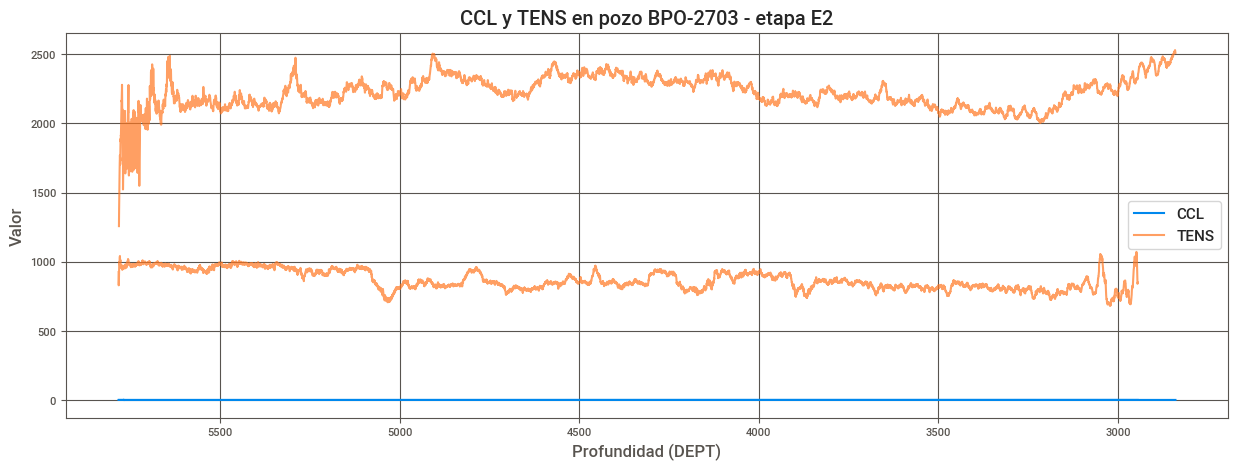

In [15]:
# Cantidad de etapas por pozo
etapas_por_pozo = df.groupby("pozo")["etapa"].nunique()
print("Etapas por pozo:")
print(etapas_por_pozo)

# Podemos graficar un resumen de una etapa específica
pozo_sample = df["pozo"].unique()[0]
etapa_sample = df[df["pozo"] == pozo_sample]["etapa"].unique()[0]

df_sample = df[(df["pozo"] == pozo_sample) & (df["etapa"] == etapa_sample)]

plt.figure(figsize=(15, 5))
plt.plot(df_sample["DEPT"], df_sample["CCL"], label="CCL")
plt.plot(df_sample["DEPT"], df_sample["TENS"], label="TENS", alpha=0.7)
plt.gca().invert_xaxis()
plt.title(f"CCL y TENS en pozo {pozo_sample} - etapa {etapa_sample}")
plt.xlabel("Profundidad (DEPT)")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


## ⚡ Celda 8 - AutoEDA con Sweetviz (opcional, pesado)

In [17]:
# Generar reporte de Sweetviz
report = sweetviz.analyze(df)
report.show_html("sweetviz_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## 📋 Celda 9 - AutoEDA con YData Profiling (antes Pandas Profiling)

In [16]:
# Puede ser pesado para muchos datos. Recomendado en subset.
profile = ProfileReport(df.sample(10000) if len(df) > 10000 else df, title="Reporte de AutoEDA", explorative=True)
profile.to_file("profile_report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 60.59it/s]
c:\Users\FSONZOGNI\AppData\Local\anaconda3\envs\CCL_Anomalias\lib\site-packages\ydata_profiling\model\correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'putmask: first argument must be an array')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## ✅ Celda 10 - Conclusiones iniciales (Markdown)

## 🧠 Conclusiones Iniciales

- Se visualizó una ...
- La tensión TENS podría ...
- Se recomienda seguir explorando correlaciones ...
- Este análisis visual servirá de base para crear ...
